# Week 1 — Data Acquisition & Exploratory Analysis

Load, clean, encode, and explore the MovieLens ml-latest-small dataset.

In [1]:
import sys
sys.path.insert(0, '../src')

from data_utils import load_and_clean_ratings, encode_ids, load_movies_with_tags

ratings = load_and_clean_ratings('../data/raw/ratings.csv', min_ratings=5)
ratings, user2idx, item2idx = encode_ids(ratings)
movies = load_movies_with_tags(
    '../data/raw/movies.csv',
    '../data/raw/tags.csv'
)

print(f"Users:    {ratings['userId'].nunique()}")
print(f"Items:    {ratings['movieId'].nunique()}")
print(f"Ratings:  {len(ratings)}")
print(f"Sparsity: {1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique()):.4f}")
print(f"\nRatings sample:")
ratings.head()

Users:    610
Items:    3650
Ratings:  90274
Sparsity: 0.9595

Ratings sample:


,userId,movieId,rating,timestamp,rating_date,user_idx,item_idx
0,1,1,4.0,964982703,2000-07-30 18:45:03,0,0
1,1,3,4.0,964981247,2000-07-30 18:20:47,0,1
2,1,6,4.0,964982224,2000-07-30 18:37:04,0,2
3,1,47,5.0,964983815,2000-07-30 19:03:35,0,3
4,1,50,5.0,964982931,2000-07-30 18:48:51,0,4


In [2]:
ratings.to_csv('../data/processed/ratings_clean.csv', index=False)
movies.to_csv('../data/processed/movies_content.csv', index=False)
print("Saved: data/processed/ratings_clean.csv")
print("Saved: data/processed/movies_content.csv")

Saved: data/processed/ratings_clean.csv
Saved: data/processed/movies_content.csv


## Plot 1 — Rating Distribution

Shows the count of each rating value. Expect a right-skew (users rate things they liked).

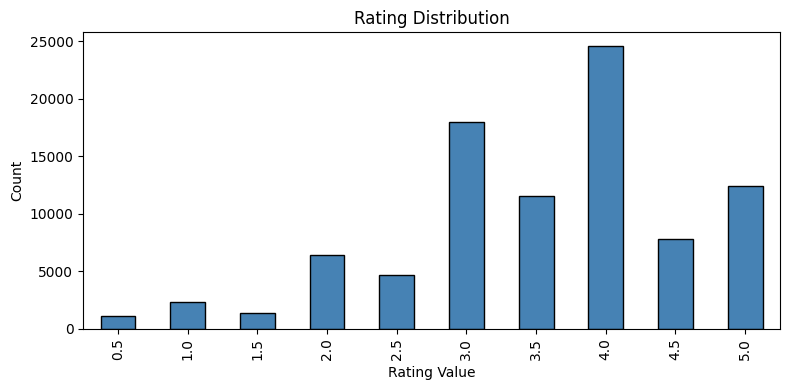

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating Value')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/viz_rating_dist.png', dpi=120)
plt.show()

## Plot 2 — User Activity Distribution

Log-scale histogram of how many ratings each user gave. Reveals power-user dominance.

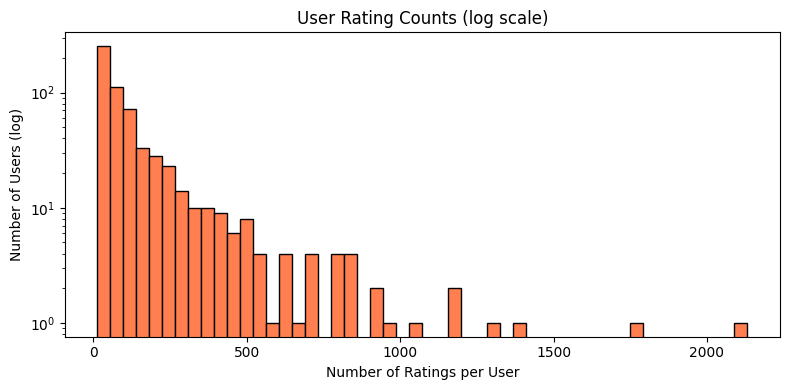

Median ratings/user: 68
Top 5% users rate:   524+ items


In [4]:
user_counts = ratings.groupby('userId').size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(user_counts, bins=50, color='coral', edgecolor='black')
ax.set_yscale('log')
ax.set_title('User Rating Counts (log scale)')
ax.set_xlabel('Number of Ratings per User')
ax.set_ylabel('Number of Users (log)')
plt.tight_layout()
plt.savefig('../data/processed/viz_user_activity.png', dpi=120)
plt.show()

print(f"Median ratings/user: {user_counts.median():.0f}")
print(f"Top 5% users rate:   {user_counts.quantile(0.95):.0f}+ items")

## Plot 3 — Item Popularity Curve

Sorted item rating counts on log-log scale. The classic power-law long tail.

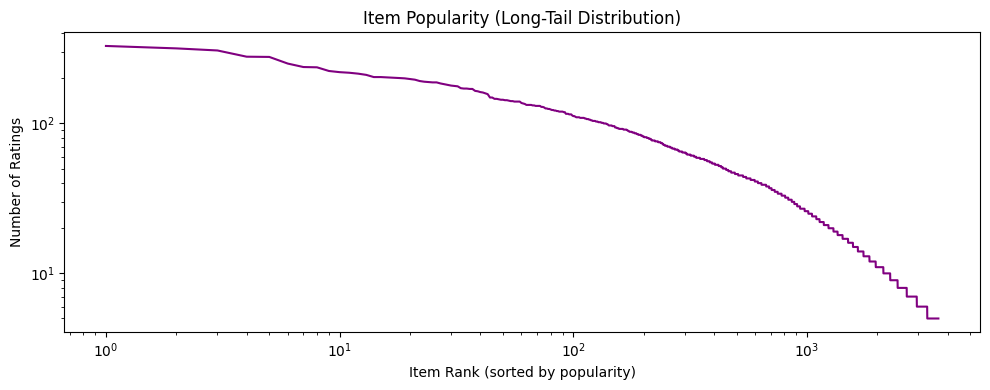

Top 1% of items account for 8.5% of all ratings


In [5]:
item_counts = ratings.groupby('movieId').size().sort_values(ascending=False).reset_index()
item_counts.columns = ['movieId', 'count']
item_counts['rank'] = range(1, len(item_counts) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(item_counts['rank'], item_counts['count'], color='purple')
ax.set_title('Item Popularity (Long-Tail Distribution)')
ax.set_xlabel('Item Rank (sorted by popularity)')
ax.set_ylabel('Number of Ratings')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../data/processed/viz_item_popularity.png', dpi=120)
plt.show()

top_1pct = item_counts.head(int(len(item_counts) * 0.01))['count'].sum()
total = item_counts['count'].sum()
print(f"Top 1% of items account for {top_1pct/total:.1%} of all ratings")

## Plot 4 — Interaction Matrix Sparsity

Heatmap of top 50 users × top 50 items. White = unobserved (missing rating).

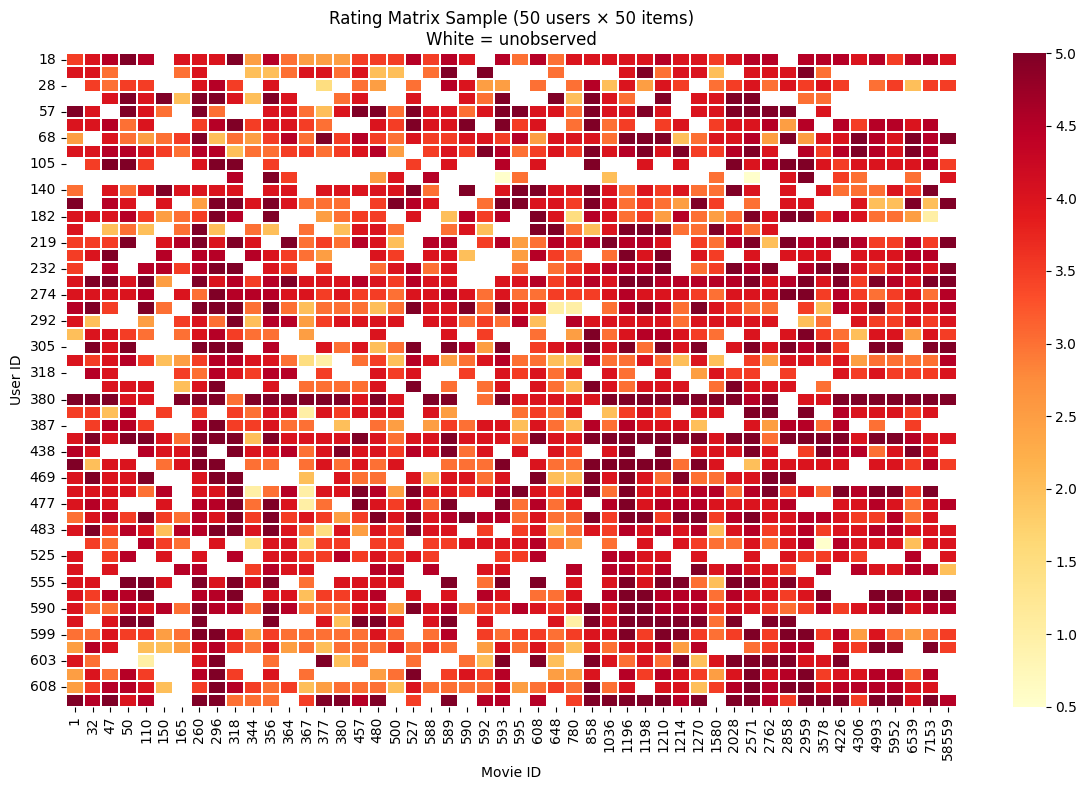

In [6]:
import numpy as np

top_users = user_counts.nlargest(50).index.tolist()
top_items = item_counts.head(50)['movieId'].tolist()

sample = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_items)]
matrix = sample.pivot_table(index='userId', columns='movieId', values='rating')

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(matrix, cmap='YlOrRd', mask=matrix.isna(), linewidths=0.1, ax=ax)
ax.set_title('Rating Matrix Sample (50 users × 50 items)\nWhite = unobserved')
ax.set_xlabel('Movie ID')
ax.set_ylabel('User ID')
plt.tight_layout()
plt.savefig('../data/processed/viz_matrix_sparsity.png', dpi=120)
plt.show()

## Plot 5 — Temporal Rating Trends

Monthly rating volume over time. Spikes or dropoffs hint at data collection artifacts.

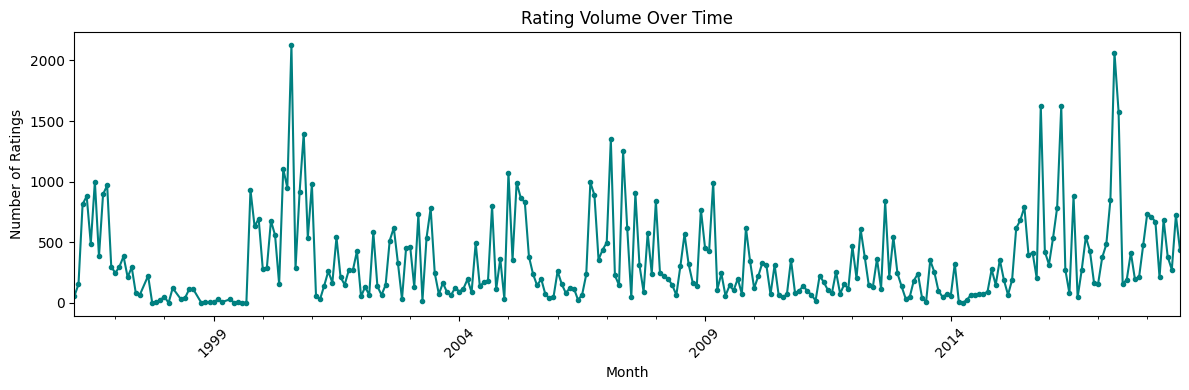

In [7]:
ratings['year_month'] = ratings['rating_date'].dt.to_period('M')
monthly = ratings.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color='teal', marker='o', markersize=3)
ax.set_title('Rating Volume Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/viz_temporal.png', dpi=120)
plt.show()